In [1]:
from src.model.source import Source
from src.backend import TorchBackend
from src.model.geometry.lattice import Lattice
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (501, 501)
M = 5
N = 5
lattice = Lattice(period=period, grid=grid, M=M, N=N)

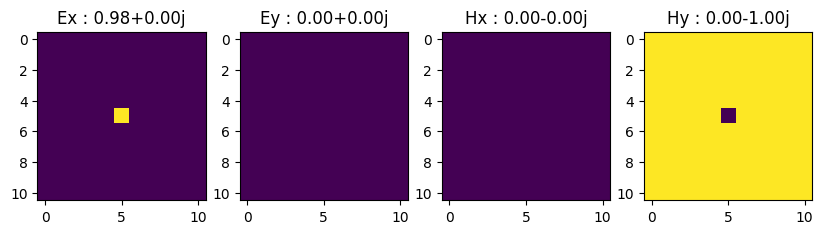

In [3]:
wavelength = torch.tensor([400, 500])
theta = torch.tensor([10, 10.0])*torch.pi/180  # normal incidence
phi = torch.tensor([0.0])*torch.pi/180    # azimuthal angle

source = Source(wavelength=wavelength, theta=theta, phi=phi)

n_inc = torch.tensor([1.0, 1.5])
k0x, k0y = source.k0xy(backend, n_inc)

Ex, Ey, Hx, Hy = source.plane_wave_field(backend, lattice, n_inc, (0, 0), s=0, p=1)

plt.figure(figsize=(10,6))
plt.subplot(141)
plt.title(f'Ex : {Ex[0,0,0][5, 5].cpu():.2f}')
plt.imshow(Ex[0,0,0].real.cpu())

plt.subplot(142)
plt.title(f'Ey : {Ey[0,0,0][5, 5].cpu():.2f}')
plt.imshow(Ey[0,0,0].real.cpu())

plt.subplot(143)
plt.title(f'Hx : {Hx[0,0,0][5, 5].cpu():.2f}')
plt.imshow(Hx[0,0,0].imag.cpu())

plt.subplot(144)
plt.title(f'Hy : {Hy[0,0,0][5, 5].cpu():.2f}')
plt.imshow(Hy[0,0,0].imag.cpu())

In [4]:
psi = source.psi_vector_inc(backend, lattice, n_inc, (0, 0), s=1, p=1, circ_truncation=True)

In [5]:
psi.shape

torch.Size([2, 2, 1, 324])